# 🧠 RAG (Retrieval-Augmented Generation) — Instructor's Deep-Dive Notebook

> **Purpose:** This is the **instructor's annotated version**. Every code block has been augmented with detailed explanations, visualizations, and additional experiments so you can teach each concept with confidence.

---

## 📖 Table of Contents
1. Why RAG Exists — The Problem
2. Dataset Loading & Exploration
3. Setting Up the LLM
4. Chunking Strategies (6 methods)
5. Embeddings — How Text Becomes Numbers
6. Vector Databases with ChromaDB
7. Advanced Retrieval: HNSW, HyDE, Cross-Encoder Reranking
8. The Complete RAG Pipeline
9. Gradio UI
10. ✨ Augmented Experiments (Cosine Similarity, Chunk Quality, Retrieval Eval)


---
## 🔍 Section 1: Why RAG Exists

### The Core Problem with LLMs

Large language models (LLMs) like GPT-4 are trained once on a snapshot of the internet. After training, their knowledge is **frozen**. This creates three major problems:

| Problem | Example | Impact |
|---|---|---|
| **Knowledge Cutoff** | Ask GPT-4 about a paper published last week | Hallucination or "I don't know" |
| **Hallucination** | Ask about your internal company policy | Confident but wrong answer |
| **Private Data** | Your proprietary documents, codebase | LLM has never seen them |

### How RAG Solves This

RAG = **Retrieve** relevant documents at query time → **Augment** the prompt with them → **Generate** a grounded answer.

```
User Query
    ↓
[Retriever] → searches your document store → returns top-k relevant chunks
    ↓
[Augmented Prompt] = "Here are the relevant docs: {...} Now answer: {query}"
    ↓
[LLM] → reads the provided context → generates grounded answer
```

The LLM never has to "remember" your data — it reads it fresh every time!

### RAG vs Fine-tuning

| | RAG | Fine-tuning |
|---|---|---|
| Data freshness | Real-time updates | Requires retraining |
| Cost | Low (inference only) | High (GPU training) |
| Transparency | Sources are traceable | Black box |
| Best for | Dynamic/private knowledge | Style/behavior changes |


---
## 📦 Section 2: Loading the Dataset

We use the **Hugging Face documentation dataset** (`m-ric/huggingface_doc`).

Why this dataset?
- Real-world technical text (not toy data)
- Large enough to make retrieval meaningful
- Has clear question-answer patterns ("How do I load a pretrained model?")


In [3]:
from datasets import load_dataset

# Load the Hugging Face documentation dataset
# split="train" gives us the full corpus
dataset = load_dataset("m-ric/huggingface_doc", split="train")

print(f"Number of documents: {len(dataset)}")
print(f"Dataset features: {dataset.features}")

/Users/rohitjindal/Desktop/SA-RI/AI Engineering/RAG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of documents: 2647
Dataset features: {'text': Value('string'), 'source': Value('string')}


### 🔍 Deep Dive: What does the dataset look like?

Each record in the dataset is a dictionary. Let's inspect its structure carefully.

In [13]:
print(dataset[0]['text'])

 Create an Endpoint

After your first login, you will be directed to the [Endpoint creation page](https://ui.endpoints.huggingface.co/new). As an example, this guide will go through the steps to deploy [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english) for text classification. 

## 1. Enter the Hugging Face Repository ID and your desired endpoint name:

<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_repository.png" alt="select repository" />

## 2. Select your Cloud Provider and region. Initially, only AWS will be available as a Cloud Provider with the `us-east-1` and `eu-west-1` regions. We will add Azure soon, and if you need to test Endpoints with other Cloud Providers or regions, please let us know.

<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_region.png" alt="select region" />

## 3. Define the [Security Level

In [7]:
# Look at a single example — understand EVERY field
example = dataset[0]

print("Sample document:")
print("-" * 60)
for key, value in example.items():
    if isinstance(value, str) and len(value) > 300:
        print(f"  {key}: {value[:300]}...")
    else:
        print(f"  {key}: {value}")

print()
print("📌 INSTRUCTOR NOTE:")
print("  The 'text' field is what we will embed and search.")
print("  The 'source' field is useful for metadata filtering.")


Sample document:
------------------------------------------------------------
  text:  Create an Endpoint

After your first login, you will be directed to the [Endpoint creation page](https://ui.endpoints.huggingface.co/new). As an example, this guide will go through the steps to deploy [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert-base-uncased-f...
  source: huggingface/hf-endpoints-documentation/blob/main/docs/source/guides/create_endpoint.mdx

📌 INSTRUCTOR NOTE:
  The 'text' field is what we will embed and search.
  The 'source' field is useful for metadata filtering.


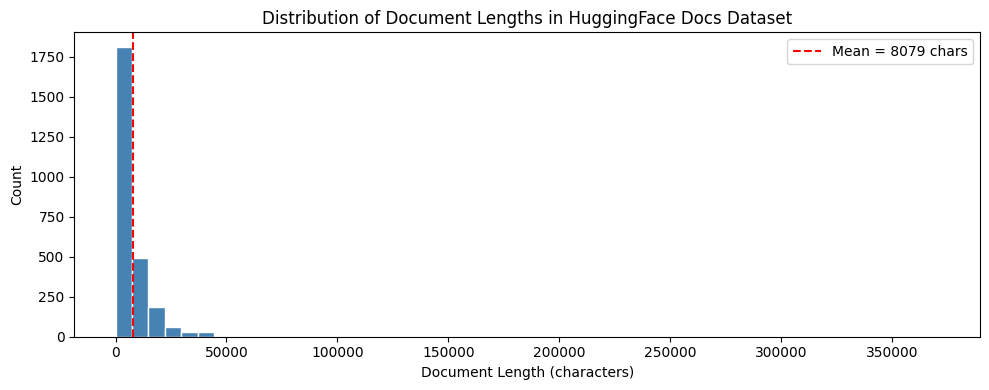

Min length    : 23 chars
Max length    : 371,057 chars
Mean length   : 8,079 chars
Median length : 4,575 chars

📌 INSTRUCTOR NOTE:
  GPT-4o-mini has a 128k token context window ≈ ~96,000 words.
  But sending ALL documents to the LLM would be:
  (a) Extremely expensive — you pay per token
  (b) Slow — more tokens = longer to process
  (c) Less accurate — LLMs struggle with very long contexts ('lost in the middle' problem)
  → This is why we need to RETRIEVE only the relevant chunks!


In [3]:
# Check text field length distribution across all documents
# This tells us: do we need chunking? (spoiler: yes!)
text_lengths = [len(doc["text"]) for doc in dataset]

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 4))
plt.hist(text_lengths, bins=50, color="steelblue", edgecolor="white")
plt.axvline(np.mean(text_lengths), color="red", linestyle="--",
            label=f"Mean = {np.mean(text_lengths):.0f} chars")
plt.xlabel("Document Length (characters)")
plt.ylabel("Count")
plt.title("Distribution of Document Lengths in HuggingFace Docs Dataset")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Min length    : {min(text_lengths):,} chars")
print(f"Max length    : {max(text_lengths):,} chars")
print(f"Mean length   : {np.mean(text_lengths):,.0f} chars")
print(f"Median length : {np.median(text_lengths):,.0f} chars")
print()
print("📌 INSTRUCTOR NOTE:")
print("  GPT-4o-mini has a 128k token context window ≈ ~96,000 words.")
print("  But sending ALL documents to the LLM would be:")
print("  (a) Extremely expensive — you pay per token")
print("  (b) Slow — more tokens = longer to process")
print("  (c) Less accurate — LLMs struggle with very long contexts ('lost in the middle' problem)")
print("  → This is why we need to RETRIEVE only the relevant chunks!")


---
## 🤖 Section 3: Setting Up the LLM

We use OpenAI's `gpt-4o-mini` — fast, cheap, and good enough for RAG tasks.

> ⚠️ **Bug fix from original notebook:** The original code defined `open_ai_client = OpenAI()` but then called `client.chat.completions...` in cell 15. We fix this below.


In [4]:
import os
import getpass

# Securely input your OpenAI API key — never hardcode it!
# getpass hides the input so it doesn't appear in the notebook
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")


In [5]:
from openai import OpenAI

# Initialize the OpenAI client
# Note: We consistently use the name 'open_ai_client' throughout this notebook
open_ai_client = OpenAI()

print("✅ OpenAI client initialized")


✅ OpenAI client initialized


In [6]:
# Basic LLM call — NO retrieval, NO augmentation
# This is the BEFORE state — pure parametric knowledge
response = open_ai_client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "user", "content": "What is the capital of France?"}
    ]
)

print("Response from LLM (parametric knowledge only):")
print(response.choices[0].message.content)

print()
print("📌 INSTRUCTOR NOTE:")
print("  This works fine for general knowledge.")
print("  Now ask: 'What does the HuggingFace AutoModel class do?'")
print("  The LLM may give a vague or outdated answer.")
print("  → RAG will fix this by injecting the actual documentation!")


Response from LLM (parametric knowledge only):
The capital of France is Paris.

📌 INSTRUCTOR NOTE:
  This works fine for general knowledge.
  Now ask: 'What does the HuggingFace AutoModel class do?'
  The LLM may give a vague or outdated answer.
  → RAG will fix this by injecting the actual documentation!


### ✨ AUGMENTED: Understanding the OpenAI API Response Object

Many learners are confused by `response.choices[0].message.content`. Let's demystify it.

In [7]:
# Let's inspect the FULL response object structure
response = open_ai_client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Say hello in one sentence."}]
)

print("=== FULL RESPONSE OBJECT ===")
print(f"Model used       : {response.model}")
print(f"Response ID      : {response.id}")
print(f"Created at       : {response.created}")
print(f"Number of choices: {len(response.choices)}")
print()
print("=== THE ACTUAL MESSAGE ===")
print(f"Role             : {response.choices[0].message.role}")
print(f"Content          : {response.choices[0].message.content}")
print()
print("=== TOKEN USAGE (this is what costs money!) ===")
print(f"Prompt tokens    : {response.usage.prompt_tokens}")
print(f"Completion tokens: {response.usage.completion_tokens}")
print(f"Total tokens     : {response.usage.total_tokens}")
print(f"Estimated cost   : ~${response.usage.total_tokens * 0.00000015:.6f} USD")


=== FULL RESPONSE OBJECT ===
Model used       : gpt-4o-mini-2024-07-18
Response ID      : chatcmpl-DJiHGg8lHWnqydjyONluP2vxgBjB5
Created at       : 1773590806
Number of choices: 1

=== THE ACTUAL MESSAGE ===
Role             : assistant
Content          : Hello! How are you today?

=== TOKEN USAGE (this is what costs money!) ===
Prompt tokens    : 13
Completion tokens: 7
Total tokens     : 20
Estimated cost   : ~$0.000003 USD


---
## ✂️ Section 4: Chunking Strategies

### Why Chunking?

LLMs have a **context window limit** (max tokens they can read at once). Even without that limit, large chunks hurt retrieval because:

- Embedding a 10-page document creates ONE vector — that vector can't represent ALL topics in the document
- Smaller, focused chunks → more precise embeddings → better retrieval

**The Goldilocks problem:** Chunks too small = lose context. Too big = dilute the embedding.

```
Chunk too small (20 tokens):
  "AutoModel.from_pretrained"  ← What does this mean alone? No context.

Chunk too large (5000 tokens):
  [entire documentation page]  ← The embedding mixes 20 different topics.

Chunk just right (128–512 tokens):
  "To load a pretrained model, use AutoModel.from_pretrained('bert-base-uncased').
   This automatically downloads weights from the Hub."  ← Clear, focused, searchable!
```


In [14]:
# Our teaching document: A blog post about productivity
# Perfect for learning chunking — clear paragraphs, distinct topics
teaching_document = """
The Art of Deep Work: A Guide to Productivity

In today's world of constant notifications and endless distractions, the ability to focus deeply on cognitively demanding tasks has become increasingly rare—and increasingly valuable. This is what author Cal Newport calls "deep work": professional activities performed in a state of distraction-free concentration that push your cognitive capabilities to their limit.

Why Deep Work Matters

Deep work is valuable for several reasons. First, it allows you to produce high-quality output in less time. When you're fully concentrated on a single task, you work more efficiently and make fewer mistakes. Second, deep work helps you master complex skills faster. Learning difficult concepts requires sustained attention—something impossible to achieve when constantly switching between tasks.

Creating Your Deep Work Environment

The first step in cultivating deep work is designing an environment that supports concentration. This means more than just finding a quiet space. Consider your physical setup: Is your desk organized? Is the lighting appropriate? Do you have everything you need within reach?

Digital distractions are equally important to address. Turn off notifications on your devices. Close unnecessary browser tabs. Use website blockers if needed. The goal is to create a space where your attention isn't constantly being pulled away from the task at hand.

Time Blocking for Deep Work

Scheduling specific blocks of time for deep work is crucial. Don't wait for free time to magically appear—it won't. Instead, treat deep work sessions as important appointments with yourself. Many people find that early morning hours work best, when their mental energy is highest and distractions are minimal.

Start with manageable blocks. If you're new to deep work, even 60-90 minutes of focused time can feel challenging. As you build your concentration muscles, gradually extend these sessions. Some professionals work up to four-hour blocks of uninterrupted deep work.

The Shutdown Ritual

Just as important as starting deep work is knowing when to stop. Develop a shutdown ritual to mark the end of your workday. This might include reviewing your task list for tomorrow, closing all work-related browser tabs, and saying a specific phrase like "shutdown complete."

This ritual serves multiple purposes. It helps you mentally disconnect from work, reduces anxiety about unfinished tasks, and ensures you've captured anything important before stepping away. Without this clear boundary, work thoughts tend to linger into your evening, preventing true rest and recovery.

Measuring Your Progress

Track your deep work hours each week. This simple metric provides valuable feedback on your habits. You might discover that you're spending less time in deep work than you thought, or that certain days of the week are more conducive to concentration than others.

Remember, the goal isn't to spend every waking hour in deep work. Even the most focused professionals typically max out at four to five hours of truly deep work per day. What matters is consistency and intentionality—making deep work a regular part of your routine rather than an occasional occurrence.
"""

print(f"Document length : {len(teaching_document):,} characters")
print(f"Word count      : {len(teaching_document.split()):,} words")
print(f"Paragraphs      : {teaching_document.count(chr(10)+chr(10))}")


Document length : 3,219 characters
Word count      : 491 words
Paragraphs      : 15


### Strategy 1: Fixed-Size Token Chunking

**Analogy:** Cutting a book into pages of exactly 128 words — clean, predictable, but might cut mid-sentence.

**When to use:** Baselines, batch processing, when you just need something working fast.

In [15]:
from chonkie import TokenChunker
from tokenizers import Tokenizer
from chonkie import Visualizer

# Tokenizer: converts words → token IDs
# GPT-2 tokenizer is a good standard reference (same family as GPT-4)
tokenizer = Tokenizer.from_pretrained("gpt2")

# Fixed-size chunker: every chunk = exactly 128 tokens, no overlap
fixed_size_chunker = TokenChunker(
    tokenizer=tokenizer,
    chunk_size=128,
    chunk_overlap=0       # No shared content between chunks
)

fixed_chunks = fixed_size_chunker.chunk(teaching_document)

print(f"Number of chunks  : {len(fixed_chunks)}")
print(f"Token counts      : {[chunk.token_count for chunk in fixed_chunks]}")
print()
print("📌 Notice: all chunks are 128 tokens (except possibly the last one)")
print("📌 Some chunks will cut mid-sentence — this is the main weakness!")

viz = Visualizer()
viz.print(fixed_chunks)


Number of chunks  : 5
Token counts      : [128, 128, 128, 128, 105]

📌 Notice: all chunks are 128 tokens (except possibly the last one)
📌 Some chunks will cut mid-sentence — this is the main weakness!


The Art of Deep Work: A Guide to Productivity

In today's world of constant notifications and endless distractions, the ability to focus deeply on cognitively 
demanding tasks has become increasingly rare—and increasingly valuable. This is what author Cal Newport calls "deep
work": professional activities performed in a state of distraction-free concentration that push your cognitive 
capabilities to their limit.

Why Deep Work Matters

Deep work is valuable for several reasons. First, it allows you to produce high-quality output in less time. When 
you're fully concentrated on a single task, you work more efficiently and make fewer mistakes. Second, deep work 
helps you master complex skills faster. Learning difficult concepts requires sustained attention—something 
impossible to achieve when constantly switching between tasks.

Creating Your Deep Work Environment

The first step in cultivating deep work is designing an environment that supports concentration. This means more 
than just finding a quiet space. Consider your physical setup: Is your desk organized? Is the lighting appropriate?
Do you have everything you need within reach?

Digital distractions are equally important to address. Turn off notifications on your devices. Close unnecessary 
browser tabs. Use website blockers if needed. The goal is to create a space where your attention isn't constantly 
being pulled away from the task at hand.

Time Blocking for Deep Work

Scheduling specific blocks of time for deep work is crucial. Don't wait for free time to magically appear—it won't.
Instead, treat deep work sessions as important appointments with yourself. Many people find that early morning 
hours work best, when their mental energy is highest and distractions are minimal.

Start with manageable blocks. If you're new to deep work, even 60-90 minutes of focused time can feel challenging. 
As you build your concentration muscles, gradually extend these sessions. Some professionals work up to four-hour 
blocks of uninterrupted deep work.

The Shutdown Ritual

Just as important as starting deep work is knowing when to stop. Develop a shutdown ritual to mark the end of your 
workday. This might include reviewing your task list for tomorrow, closing all work-related browser tabs, and 
saying a specific phrase like "shutdown complete."

This ritual serves multiple purposes. It helps you mentally disconnect from work, reduces anxiety about unfinished 
tasks, and ensures you've captured anything important before stepping away. Without this clear boundary, work 
thoughts tend to linger into your evening, preventing true rest and recovery.

Measuring Your Progress

Track your deep work hours each week. This simple metric provides valuable feedback on your habits. You might 
discover that you're spending less time in deep work than you thought, or that certain days of the week are more 
conducive to concentration than others.

Remember, the goal isn't to spend every waking hour in deep work. Even the most focused professionals typically max
out at four to five hours of truly deep work per day. What matters is consistency and intentionality—making deep 
work a regular part of your routine rather than an occasional occurrence.

In [23]:
fixed_chunks[3]

Chunk(text='

The Shutdown Ritual

Just as important as starting deep work is knowing when to stop. Develop a shutdown ritual to mark the end of your workday. This might include reviewing your task list for tomorrow, closing all work-related browser tabs, and saying a specific phrase like "shutdown complete."

This ritual serves multiple purposes. It helps you mentally disconnect from work, reduces anxiety about unfinished tasks, and ensures you've captured anything important before stepping away. Without this clear boundary, work thoughts tend to linger into your evening, preventing true rest and recovery.

Measuring Your Progress

Track your deep work hours', token_count=128, start_index=2023, end_index=2678)

### ✨ AUGMENTED: Inspecting chunk content manually

Let's look at the actual text boundaries to see mid-sentence cuts.

In [11]:
print("=== BOUNDARY INSPECTION: Where do chunks start and end? ===\n")
for i, chunk in enumerate(fixed_chunks):
    text = chunk.text.strip()
    last_words = text[-80:] if len(text) > 80 else text
    first_words = text[:80] if len(text) > 80 else text
    print(f"Chunk {i+1:02d} | Start: ...{first_words[:40]!r}")
    print(f"        | End  : ...{last_words[-40:]!r}")
    print(f"        | Tokens: {chunk.token_count}")
    print()


=== BOUNDARY INSPECTION: Where do chunks start and end? ===

Chunk 01 | Start: ...'The Art of Deep Work: A Guide to Product'
        | End  : ...'ly and make fewer mistakes. Second, deep'
        | Tokens: 128

Chunk 02 | Start: ...'work helps you master complex skills fas'
        | End  : ..." isn't constantly being pulled away from"
        | Tokens: 128

Chunk 03 | Start: ...'the task at hand.\n\nTime Blocking for Dee'
        | End  : ...'-hour blocks of uninterrupted deep work.'
        | Tokens: 128

Chunk 04 | Start: ...'The Shutdown Ritual\n\nJust as important a'
        | End  : ...'our Progress\n\nTrack your deep work hours'
        | Tokens: 128

Chunk 05 | Start: ...'each week. This simple metric provides v'
        | End  : ...'ne rather than an occasional occurrence.'
        | Tokens: 105



### Strategy 2: Token Chunking with Overlap

**Analogy:** Cutting the same book into pages of 128 words, but each new page REPEATS the last 32 words of the previous page. 

**Why this helps:** If "time blocking" spans chunks 2 and 3, the overlap ensures chunk 3 starts with enough context to understand the continuation.

**Rule of thumb:** 25% overlap (chunk_overlap = chunk_size / 4) works well for most cases.

In [ ]:
overlap_chunker = TokenChunker(
    tokenizer=tokenizer,
    chunk_size=128,
    chunk_overlap=32    
)

overlap_chunks = overlap_chunker.chunk(teaching_document)

print(f"Number of chunks (no overlap) : {len(fixed_chunks)}")
print(f"Number of chunks (32 overlap) : {len(overlap_chunks)}")
print(f"Extra chunks due to overlap   : {len(overlap_chunks) - len(fixed_chunks)}")
print()
print("📌 More chunks = more storage, but better context preservation")
print("📌 For production: overlap of 10-20% is a common sweet spot")

viz.print(overlap_chunks)


Number of chunks (no overlap) : 5
Number of chunks (32 overlap) : 7
Extra chunks due to overlap   : 2

📌 More chunks = more storage, but better context preservation
📌 For production: overlap of 10-20% is a common sweet spot


The Art of Deep Work: A Guide to Productivity

In today's world of constant notifications and endless distractions, the ability to focus deeply on cognitively 
demanding tasks has become increasingly rare—and increasingly valuable. This is what author Cal Newport calls "deep
work": professional activities performed in a state of distraction-free concentration that push your cognitive 
capabilities to their limit.

Why Deep Work Matters

Deep work is valuable for several reasons. First, it allows you to produce high-quality output in less time. When 
you're fully concentrated on a single task, you work more efficiently and make fewer mistakes. Second, deep work 
helps you master complex skills faster. Learning difficult concepts requires sustained attention—something 
impossible to achieve when constantly switching between tasks.

Creating Your Deep Work Environment

The first step in cultivating deep work is designing an environment that supports concentration. This means more 
than just finding a quiet space. Consider your physical setup: Is your desk organized? Is the lighting appropriate?
Do you have everything you need within reach?

Digital distractions are equally important to address. Turn off notifications on your devices. Close unnecessary 
browser tabs. Use website blockers if needed. The goal is to create a space where your attention isn't constantly 
being pulled away from the task at hand.

Time Blocking for Deep Work

Scheduling specific blocks of time for deep work is crucial. Don't wait for free time to magically appear—it won't.
Instead, treat deep work sessions as important appointments with yourself. Many people find that early morning 
hours work best, when their mental energy is highest and distractions are minimal.

Start with manageable blocks. If you're new to deep work, even 60-90 minutes of focused time can feel challenging. 
As you build your concentration muscles, gradually extend these sessions. Some professionals work up to four-hour 
blocks of uninterrupted deep work.

The Shutdown Ritual

Just as important as starting deep work is knowing when to stop. Develop a shutdown ritual to mark the end of your 
workday. This might include reviewing your task list for tomorrow, closing all work-related browser tabs, and 
saying a specific phrase like "shutdown complete."

This ritual serves multiple purposes. It helps you mentally disconnect from work, reduces anxiety about unfinished 
tasks, and ensures you've captured anything important before stepping away. Without this clear boundary, work 
thoughts tend to linger into your evening, preventing true rest and recovery.

Measuring Your Progress

Track your deep work hours each week. This simple metric provides valuable feedback on your habits. You might 
discover that you're spending less time in deep work than you thought, or that certain days of the week are more 
conducive to concentration than others.

Remember, the goal isn't to spend every waking hour in deep work. Even the most focused professionals typically max
out at four to five hours of truly deep work per day. What matters is consistency and intentionality—making deep 
work a regular part of your routine rather than an occasional occurrence.

### ✨ AUGMENTED: Proving the overlap exists

Let's programmatically verify that adjacent chunks share text.

In [13]:
print("=== PROVING OVERLAP EXISTS ===\n")
for i in range(min(3, len(overlap_chunks) - 1)):
    chunk_a = overlap_chunks[i].text
    chunk_b = overlap_chunks[i+1].text
    
    # Find common words between end of chunk A and start of chunk B
    words_a = chunk_a.split()
    words_b = chunk_b.split()
    
    # Look for the shared suffix of A in the prefix of B
    shared = []
    for k in range(min(40, len(words_a))):
        suffix = " ".join(words_a[-(k+1):])
        if suffix in chunk_b[:200]:
            shared = words_a[-(k+1):]
    
    print(f"Chunks {i+1} → {i+2}:")
    if shared:
        print(f"  Shared text: '...{' '.join(shared[:10])}...'")
    else:
        print(f"  No overlap detected at this boundary")
    print()


=== PROVING OVERLAP EXISTS ===

Chunks 1 → 2:
  Shared text: '...to produce high-quality output in less time. When you're fully...'

Chunks 2 → 3:
  Shared text: '...Digital distractions are equally important to address. Turn off notifications...'

Chunks 3 → 4:
  Shared text: '...free time to magically appear—it won't. Instead, treat deep work...'



Read the document sentence by sentence.

Convert sentences into embeddings.

Look at 3 sentences at a time.

If the semantic similarity between windows drops below 0.7,
consider that a topic change and split the chunk.

Also split if the chunk grows beyond 512 tokens.

### Strategy 3: Semantic Chunking

**Analogy:** Instead of a ruler, use a human reader who says "this paragraph is about Topic A, the next switches to Topic B — let's split here."

**How it works:**
1. Split into sentences
2. Embed each sentence
3. Compute cosine similarity between adjacent sentences
4. Split where similarity drops below threshold (different topics!)

**Threshold:** Higher threshold = more splits (smaller, more focused chunks). Lower = larger chunks that may mix topics.

In [25]:
from chonkie import SemanticChunker

semantic_chunker = SemanticChunker(
    embedding_model="minishlab/potion-base-32M",  # Tiny but effective model
    threshold=0.7,           # Split if similarity < 0.7 (topic change detected)
    chunk_size=512,          # Maximum size even if no topic change detected
    similarity_window=3      # Look at 3 sentences together when computing similarity
)

semantic_chunks = semantic_chunker.chunk(teaching_document)

print(f"Fixed chunks   : {len(fixed_chunks)} chunks")
print(f"Semantic chunks: {len(semantic_chunks)} chunks")
print(f"Token counts   : {[chunk.token_count for chunk in semantic_chunks]}")
print()
print("📌 Notice: chunks have VARIABLE sizes — they follow natural topic boundaries!")
print("📌 Each chunk should be a coherent, stand-alone idea")

viz.print(semantic_chunks)

Fixed chunks   : 5 chunks
Semantic chunks: 12 chunks
Token counts   : [84, 93, 15, 9, 8, 18, 88, 109, 52, 3, 8, 101]

📌 Notice: chunks have VARIABLE sizes — they follow natural topic boundaries!
📌 Each chunk should be a coherent, stand-alone idea


The Art of Deep Work: A Guide to Productivity

In today's world of constant notifications and endless distractions, the ability to focus deeply on cognitively 
demanding tasks has become increasingly rare—and increasingly valuable. This is what author Cal Newport calls "deep
work": professional activities performed in a state of distraction-free concentration that push your cognitive 
capabilities to their limit.

Why Deep Work Matters

Deep work is valuable for several reasons. First, it allows you to produce high-quality output in less time. When 
you're fully concentrated on a single task, you work more efficiently and make fewer mistakes. Second, deep work 
helps you master complex skills faster. Learning difficult concepts requires sustained attention—something 
impossible to achieve when constantly switching between tasks.

Creating Your Deep Work Environment

The first step in cultivating deep work is designing an environment that supports concentration. This means more 
than just finding a quiet space. Consider your physical setup: Is your desk organized? Is the lighting appropriate?
Do you have everything you need within reach?

Digital distractions are equally important to address. Turn off notifications on your devices. Close unnecessary 
browser tabs. Use website blockers if needed. The goal is to create a space where your attention isn't constantly 
being pulled away from the task at hand.

Time Blocking for Deep Work

Scheduling specific blocks of time for deep work is crucial. Don't wait for free time to magically appear—it won't.
Instead, treat deep work sessions as important appointments with yourself. Many people find that early morning 
hours work best, when their mental energy is highest and distractions are minimal.

Start with manageable blocks. If you're new to deep work, even 60-90 minutes of focused time can feel challenging. 
As you build your concentration muscles, gradually extend these sessions. Some professionals work up to four-hour 
blocks of uninterrupted deep work.

The Shutdown Ritual

Just as important as starting deep work is knowing when to stop. Develop a shutdown ritual to mark the end of your 
workday. This might include reviewing your task list for tomorrow, closing all work-related browser tabs, and 
saying a specific phrase like "shutdown complete."

This ritual serves multiple purposes. It helps you mentally disconnect from work, reduces anxiety about unfinished 
tasks, and ensures you've captured anything important before stepping away. Without this clear boundary, work 
thoughts tend to linger into your evening, preventing true rest and recovery.

Measuring Your Progress

Track your deep work hours each week. This simple metric provides valuable feedback on your habits. You might 
discover that you're spending less time in deep work than you thought, or that certain days of the week are more 
conducive to concentration than others.

Remember, the goal isn't to spend every waking hour in deep work. Even the most focused professionals typically max
out at four to five hours of truly deep work per day. What matters is consistency and intentionality—making deep 
work a regular part of your routine rather than an occasional occurrence.

### ✨ AUGMENTED: Visualizing why semantic chunking splits where it does

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7737.32it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


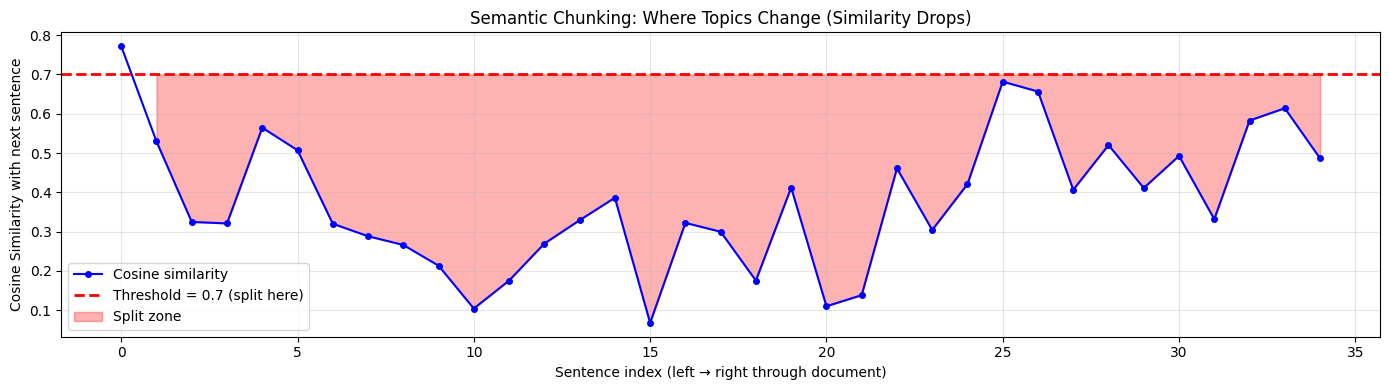

📌 Red zones = where semantic chunker will split
📌 Low similarity between consecutive sentences = topic change


In [26]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

# Use a lightweight model to embed sentences and show similarity drops
_mini_model = SentenceTransformer("all-MiniLM-L6-v2")

# Split our document into sentences
import re
sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', teaching_document) if len(s.strip()) > 20]

# Embed all sentences
sent_embeddings = _mini_model.encode(sentences)

# Compute cosine similarity between consecutive sentences
similarities = []
for i in range(len(sent_embeddings) - 1):
    sim = cosine_similarity(
        sent_embeddings[i].reshape(1, -1),
        sent_embeddings[i+1].reshape(1, -1)
    )[0][0]
    similarities.append(sim)

# Plot
plt.figure(figsize=(14, 4))
plt.plot(similarities, 'b-o', markersize=4, linewidth=1.5, label="Cosine similarity")
plt.axhline(0.7, color='red', linestyle='--', linewidth=2, label="Threshold = 0.7 (split here)")
plt.fill_between(range(len(similarities)), similarities, 0.7,
                 where=[s < 0.7 for s in similarities],
                 alpha=0.3, color='red', label="Split zone")
plt.xlabel("Sentence index (left → right through document)")
plt.ylabel("Cosine Similarity with next sentence")
plt.title("Semantic Chunking: Where Topics Change (Similarity Drops)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📌 Red zones = where semantic chunker will split")
print("📌 Low similarity between consecutive sentences = topic change")


### Strategy 4: Recursive Chunking

**Analogy:** Respects the table of contents. Splits at H1 first, then H2, then H3, then paragraphs, then sentences — always trying the "biggest" logical unit first.

**Best for:** Markdown docs, HTML, PDFs with clear headers.

In [ ]:
from chonkie import RecursiveChunker

markdown_document = """
# The Art of Deep Work: A Guide to Productivity\n
In today's world of constant notifications and endless distractions...\n\n


## Why Deep Work Matters\n
Deep work is valuable for several reasons...\n\n


## Creating Your Deep Work Environment\n
The first step in cultivating deep work...\n\n


### Physical Setup\n
Consider your physical setup: Is your desk organized?...\n\n


### Digital Distractions\n
Digital distractions are equally important to address...\n\n


## Time Blocking for Deep Work\n
Scheduling specific blocks of time for deep work is crucial...\n\n
"""

recursive_chunker = RecursiveChunker(
    tokenizer=tokenizer,
    chunk_size=15,   
)

recursive_chunks = recursive_chunker.chunk(markdown_document)

print(f"Number of chunks: {len(recursive_chunks)}")
print(f"Token counts    : {[chunk.token_count for chunk in recursive_chunks]}")
print()
print("📌 Notice: Chunks follow markdown structure (# headers define boundaries)")
print("📌 In production use chunk_size=256-512 for richer chunks")

viz.print(recursive_chunks)


Number of chunks: 11
Token counts    : [14, 14, 6, 11, 7, 15, 14, 5, 11, 8, 15]

📌 Notice: Chunks follow markdown structure (# headers define boundaries)
📌 In production use chunk_size=256-512 for richer chunks


# The Art of Deep Work: A Guide to Productivity

In today's world of constant notifications and endless distractions...




## Why Deep Work Matters

Deep work is valuable for several reasons...




## Creating Your Deep Work Environment

The first step in cultivating deep work...




### Physical Setup

Consider your physical setup: Is your desk organized?...




### Digital Distractions

Digital distractions are equally important to address...




## Time Blocking for Deep Work

Scheduling specific blocks of time for deep work is crucial...

### Strategy 5: Late Chunking

**Key insight:** In standard RAG, you chunk FIRST then embed. This means each chunk's embedding is computed WITHOUT seeing the rest of the document.

**Problem:** If chunk 5 says "As mentioned above, this applies to...", the embedding of chunk 5 doesn't know what "above" refers to.

**Late chunking fix:** Embed the ENTIRE document first (preserving full context), then split the embeddings. Each chunk still knows about the whole document!

In [18]:
from chonkie import LateChunker

late_chunker = LateChunker(
    embedding_model="minishlab/potion-base-32M",
    chunk_size=512,
)

late_chunks = late_chunker.chunk(teaching_document)

print(f"Number of chunks: {len(late_chunks)}")
print(f"Token counts    : {[chunk.token_count for chunk in late_chunks]}")
print()
print("📌 The chunks LOOK the same as token chunks")
print("📌 But their EMBEDDINGS are fundamentally different — they carry full-document context!")
print("📌 This matters most for long documents with cross-references")

viz.print(late_chunks)


Number of chunks: 2
Token counts    : [1, 1]

📌 The chunks LOOK the same as token chunks
📌 But their EMBEDDINGS are fundamentally different — they carry full-document context!
📌 This matters most for long documents with cross-references


The Art of Deep Work: A Guide to Productivity

In today's world of constant notifications and endless distractions, the ability to focus deeply on cognitively 
demanding tasks has become increasingly rare—and increasingly valuable. This is what author Cal Newport calls "deep
work": professional activities performed in a state of distraction-free concentration that push your cognitive 
capabilities to their limit.

Why Deep Work Matters

Deep work is valuable for several reasons. First, it allows you to produce high-quality output in less time. When 
you're fully concentrated on a single task, you work more efficiently and make fewer mistakes. Second, deep work 
helps you master complex skills faster. Learning difficult concepts requires sustained attention—something 
impossible to achieve when constantly switching between tasks.

Creating Your Deep Work Environment

The first step in cultivating deep work is designing an environment that supports concentration. This means more 
than just finding a quiet space. Consider your physical setup: Is your desk organized? Is the lighting appropriate?
Do you have everything you need within reach?

Digital distractions are equally important to address. Turn off notifications on your devices. Close unnecessary 
browser tabs. Use website blockers if needed. The goal is to create a space where your attention isn't constantly 
being pulled away from the task at hand.

Time Blocking for Deep Work

Scheduling specific blocks of time for deep work is crucial. Don't wait for free time to magically appear—it won't.
Instead, treat deep work sessions as important appointments with yourself. Many people find that early morning 
hours work best, when their mental energy is highest and distractions are minimal.

Start with manageable blocks. If you're new to deep work, even 60-90 minutes of focused time can feel challenging. 
As you build your concentration muscles, gradually extend these sessions. Some professionals work up to four-hour 
blocks of uninterrupted deep work.

The Shutdown Ritual

Just as important as starting deep work is knowing when to stop. Develop a shutdown ritual to mark the end of your 
workday. This might include reviewing your task list for tomorrow, closing all work-related browser tabs, and 
saying a specific phrase like "shutdown complete."

This ritual serves multiple purposes. It helps you mentally disconnect from work, reduces anxiety about unfinished 
tasks, and ensures you've captured anything important before stepping away. Without this clear boundary, work 
thoughts tend to linger into your evening, preventing true rest and recovery.

Measuring Your Progress

Track your deep work hours each week. This simple metric provides valuable feedback on your habits. You might 
discover that you're spending less time in deep work than you thought, or that certain days of the week are more 
conducive to concentration than others.

Remember, the goal isn't to spend every waking hour in deep work. Even the most focused professionals typically max
out at four to five hours of truly deep work per day. What matters is consistency and intentionality—making deep 
work a regular part of your routine rather than an occasional occurrence.

### Strategy 6: LLM-Based Agentic Chunking (SlumberChunker)

**Most powerful, most expensive.** An LLM reads the document and decides where to split based on semantic intent, not just similarity scores.

**Think of it as:** Hiring a human editor to cut your document into logical sections.

In [19]:
from chonkie import SlumberChunker
from chonkie.genie import OpenAIGenie
import os

if "OPENAI_API_KEY" not in os.environ:
    import getpass
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

genie = OpenAIGenie(model="gpt-4o-mini")

llm_chunker = SlumberChunker(
    genie=genie,
    tokenizer="gpt2",
    chunk_size=512,
    candidate_size=128,           # Window the LLM reads to decide on splits
    min_characters_per_chunk=50   # Avoid tiny chunks
)

llm_chunks = llm_chunker.chunk(teaching_document)

print(f"Number of chunks: {len(llm_chunks)}")
print(f"Token counts    : {[chunk.token_count for chunk in llm_chunks]}")
print()
print("📌 Each chunk should align perfectly with a logical section")
print("📌 This is the HIGHEST quality but SLOWEST and most EXPENSIVE method")
print("📌 Reserve for high-value documents: legal, medical, financial")

viz.print(llm_chunks)


🦛 choooooooooooooooooooonk 100% • 10/10 splits processed [00:04<00:00,  2.26split/s] 🌱

Number of chunks: 2
Token counts    : [499, 109]

📌 Each chunk should align perfectly with a logical section
📌 This is the HIGHEST quality but SLOWEST and most EXPENSIVE method
📌 Reserve for high-value documents: legal, medical, financial


The Art of Deep Work: A Guide to Productivity

In today's world of constant notifications and endless distractions, the ability to focus deeply on cognitively 
demanding tasks has become increasingly rare—and increasingly valuable. This is what author Cal Newport calls "deep
work": professional activities performed in a state of distraction-free concentration that push your cognitive 
capabilities to their limit.

Why Deep Work Matters

Deep work is valuable for several reasons. First, it allows you to produce high-quality output in less time. When 
you're fully concentrated on a single task, you work more efficiently and make fewer mistakes. Second, deep work 
helps you master complex skills faster. Learning difficult concepts requires sustained attention—something 
impossible to achieve when constantly switching between tasks.

Creating Your Deep Work Environment

The first step in cultivating deep work is designing an environment that supports concentration. This means more 
than just finding a quiet space. Consider your physical setup: Is your desk organized? Is the lighting appropriate?
Do you have everything you need within reach?

Digital distractions are equally important to address. Turn off notifications on your devices. Close unnecessary 
browser tabs. Use website blockers if needed. The goal is to create a space where your attention isn't constantly 
being pulled away from the task at hand.

Time Blocking for Deep Work

Scheduling specific blocks of time for deep work is crucial. Don't wait for free time to magically appear—it won't.
Instead, treat deep work sessions as important appointments with yourself. Many people find that early morning 
hours work best, when their mental energy is highest and distractions are minimal.

Start with manageable blocks. If you're new to deep work, even 60-90 minutes of focused time can feel challenging. 
As you build your concentration muscles, gradually extend these sessions. Some professionals work up to four-hour 
blocks of uninterrupted deep work.

The Shutdown Ritual

Just as important as starting deep work is knowing when to stop. Develop a shutdown ritual to mark the end of your 
workday. This might include reviewing your task list for tomorrow, closing all work-related browser tabs, and 
saying a specific phrase like "shutdown complete."

This ritual serves multiple purposes. It helps you mentally disconnect from work, reduces anxiety about unfinished 
tasks, and ensures you've captured anything important before stepping away. Without this clear boundary, work 
thoughts tend to linger into your evening, preventing true rest and recovery.

Measuring Your Progress

Track your deep work hours each week. This simple metric provides valuable feedback on your habits. You might 
discover that you're spending less time in deep work than you thought, or that certain days of the week are more 
conducive to concentration than others.

Remember, the goal isn't to spend every waking hour in deep work. Even the most focused professionals typically max
out at four to five hours of truly deep work per day. What matters is consistency and intentionality—making deep 
work a regular part of your routine rather than an occasional occurrence.

### ✨ AUGMENTED: Side-by-Side Chunk Comparison

Let's compare all strategies on the same passage to see the difference clearly.

In [20]:
# Compare chunk counts and size distributions
strategy_results = {
    "Fixed (no overlap)": fixed_chunks,
    "Fixed (32 overlap)": overlap_chunks,
    "Semantic"          : semantic_chunks,
}

print("=" * 65)
print(f"{'Strategy':<22} | {'# Chunks':>8} | {'Min tok':>8} | {'Max tok':>8} | {'Avg tok':>8}")
print("=" * 65)

for name, chunks in strategy_results.items():
    token_counts = [c.token_count for c in chunks]
    print(f"{name:<22} | {len(chunks):>8} | {min(token_counts):>8} | {max(token_counts):>8} | {sum(token_counts)/len(token_counts):>8.1f}")

print("=" * 65)
print()
print("📌 KEY INSIGHT:")
print("  Fixed chunks = uniform sizes (predictable but ignores meaning)")
print("  Overlap chunks = more chunks (better context, more storage)")
print("  Semantic chunks = variable sizes (follows topics, best quality)")


Strategy               | # Chunks |  Min tok |  Max tok |  Avg tok
Fixed (no overlap)     |        5 |      105 |      128 |    123.4
Fixed (32 overlap)     |        7 |       41 |      128 |    115.6
Semantic               |       12 |        3 |      109 |     49.0

📌 KEY INSIGHT:
  Fixed chunks = uniform sizes (predictable but ignores meaning)
  Overlap chunks = more chunks (better context, more storage)
  Semantic chunks = variable sizes (follows topics, best quality)


---
## 🔢 Section 5: Embeddings — How Text Becomes Numbers

### The Core Idea

An embedding converts a piece of text into a **dense vector** (list of numbers). Similar texts get similar vectors.

```
"How do I load a model?"          → [0.12, -0.34, 0.67, ...]  ← 384 numbers
"Loading pretrained weights"       → [0.11, -0.35, 0.68, ...]  ← Very similar!
"The weather in Paris is nice"    → [-0.82, 0.21, -0.11, ...] ← Very different!
```

The "distance" between vectors = the semantic dissimilarity between texts.

### What model are we using?

`all-MiniLM-L6-v2`:
- 384-dimensional embeddings
- 22M parameters (tiny and fast)
- Trained specifically for semantic similarity
- Free and runs locally on CPU


In [21]:
!pip install -q sentence-transformers



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [27]:
from sentence_transformers import SentenceTransformer

# Load pre-trained embedding model
# "all-MiniLM-L6-v2" is the go-to choice for beginners:
# fast, free, 384-dim, works well for semantic search
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Model: all-MiniLM-L6-v2")
print(f"Embedding dimension: {embedding_model.get_sentence_embedding_dimension()}")
print()

# Chunk the full HuggingFace documentation dataset
from chonkie import TokenChunker
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_pretrained("gpt2")
chunker = TokenChunker(tokenizer=tokenizer, chunk_size=256, chunk_overlap=32)

all_chunks = []
for doc in dataset:
    doc_chunks = chunker.chunk(doc["text"])
    all_chunks.extend(doc_chunks)

print(f"Total chunks from full dataset: {len(all_chunks):,}")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8951.05it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: all-MiniLM-L6-v2
Embedding dimension: 384

Total chunks from full dataset: 33,769


In [28]:
# Extract text from chunks
chunk_texts = [chunk.text for chunk in all_chunks]

print(f"Number of chunks to embed: {len(chunk_texts):,}")
print(f"Sample chunk (first 200 chars): {chunk_texts[0][:200]}...")


Number of chunks to embed: 33,769
Sample chunk (first 200 chars):  Create an Endpoint

After your first login, you will be directed to the [Endpoint creation page](https://ui.endpoints.huggingface.co/new). As an example, this guide will go through the steps to deplo...


In [24]:
import numpy as np

# Generate embeddings for first 200 chunks (subset for speed)
# In production: embed ALL chunks and store in vector DB
embeddings = embedding_model.encode(chunk_texts[:200], show_progress_bar=True)

print(f"Embeddings shape: {embeddings.shape}")
print(f"  → {embeddings.shape[0]} chunks, each represented by {embeddings.shape[1]} numbers")
print(f"Memory for 200 chunks: {embeddings.nbytes / 1024:.1f} KB")
print(f"Memory for ALL {len(chunk_texts):,} chunks: ~{embeddings.nbytes * len(chunk_texts) / 200 / 1024 / 1024:.1f} MB")


Batches: 100%|██████████| 7/7 [00:01<00:00,  3.86it/s]

Embeddings shape: (200, 384)
  → 200 chunks, each represented by 384 numbers
Memory for 200 chunks: 300.0 KB
Memory for ALL 33,769 chunks: ~49.5 MB


### ✨ AUGMENTED: Understanding Cosine Similarity

The distance metric used in vector search. Let's see how it works hands-on.

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

# Embed some test sentences to demonstrate similarity
test_sentences = [
    "How do I load a pretrained model?",       # Query
    "Loading pretrained weights from the Hub", # Relevant (similar meaning)
    "The AutoModel.from_pretrained() method",   # Relevant (same topic)
    "How to train a model from scratch",        # Partially related
    "What is the weather in Paris today",       # Completely unrelated
]


In [30]:
test_embeddings = embedding_model.encode(test_sentences)

In [31]:
# Compute all pairwise similarities
sim_matrix = cosine_similarity(test_embeddings)

In [34]:
sim_matrix

array([[ 0.99999994,  0.60132074,  0.6871836 ,  0.64652383, -0.02386465],
       [ 0.60132074,  0.9999999 ,  0.45757115,  0.324725  , -0.0640487 ],
       [ 0.6871836 ,  0.45757115,  1.0000001 ,  0.51184887,  0.00486269],
       [ 0.64652383,  0.324725  ,  0.51184887,  0.9999999 ,  0.0216652 ],
       [-0.02386465, -0.0640487 ,  0.00486269,  0.0216652 ,  1.        ]],
      dtype=float32)

In [35]:


# Display similarity of each sentence vs the query (sentence 0)
query = test_sentences[0]
print(f"Query: '{query}'\n")
print(f"{'Sentence':<50} | {'Similarity':>10}")
print("-" * 65)
for i, (sent, sim) in enumerate(zip(test_sentences, sim_matrix[0])):
    marker = " ← QUERY" if i == 0 else ""
    bar = "█" * int(sim * 20)
    print(f"{sent:<50} | {sim:>8.4f}  {bar}{marker}")

print()
print("📌 Cosine similarity ranges from -1 to 1")
print("   1.0 = identical,  0.0 = unrelated,  -1.0 = opposite")
print("   In practice, unrelated text is usually 0.1-0.3, related is 0.7+")


Query: 'How do I load a pretrained model?'

Sentence                                           | Similarity
-----------------------------------------------------------------
How do I load a pretrained model?                  |   1.0000  ███████████████████ ← QUERY
Loading pretrained weights from the Hub            |   0.6013  ████████████
The AutoModel.from_pretrained() method             |   0.6872  █████████████
How to train a model from scratch                  |   0.6465  ████████████
What is the weather in Paris today                 |  -0.0239  

📌 Cosine similarity ranges from -1 to 1
   1.0 = identical,  0.0 = unrelated,  -1.0 = opposite
   In practice, unrelated text is usually 0.1-0.3, related is 0.7+


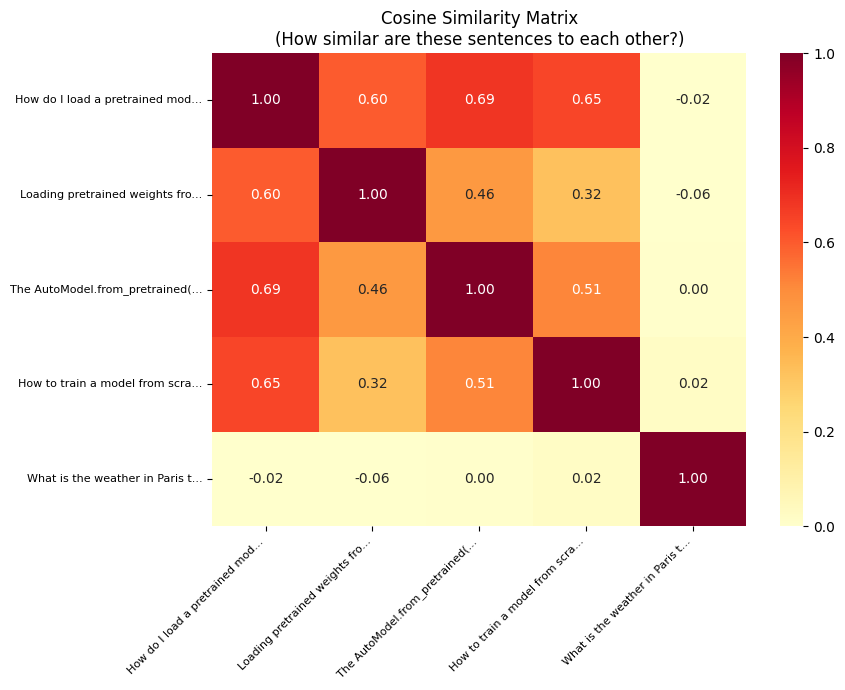

📌 This is exactly what ChromaDB does for every query!
📌 It finds the rows with the highest similarity to the query embedding


In [36]:
# Visualize the similarity MATRIX as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns

short_labels = [s[:30] + "..." if len(s) > 30 else s for s in test_sentences]

plt.figure(figsize=(9, 7))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=short_labels, yticklabels=short_labels,
            vmin=0, vmax=1)
plt.title("Cosine Similarity Matrix\n(How similar are these sentences to each other?)")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print("📌 This is exactly what ChromaDB does for every query!")
print("📌 It finds the rows with the highest similarity to the query embedding")


---
## 🗄️ Section 6: Vector Databases with ChromaDB

### Why Not Just Use NumPy?

With 200 chunks, you could compute cosine similarity with NumPy. With 200,000 chunks, this becomes:
- 200,000 × 384 numbers = **76M comparisons per query**
- At production scale (millions of docs) → too slow

**ChromaDB** handles:
1. Storing embeddings efficiently
2. Fast approximate nearest-neighbor search (HNSW)
3. Metadata filtering
4. Persistence (save/load from disk)


In [27]:
!pip install -q chromadb



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [37]:
import chromadb
from chromadb.utils import embedding_functions

In [39]:

# In-memory client for demos
# For production: chromadb.PersistentClient(path="./chroma_db")
client = chromadb.Client()

# Collection = like a table in a relational DB
# But instead of rows, it stores (id, text, embedding, metadata) tuples
collection = client.create_collection(
    name="huggingface_docs",
    metadata={"description": "Hugging Face documentation chunks"}
)


print("✅ ChromaDB collection created")
print(f"   Collection name: {collection.name}")
print(f"   Documents stored: {collection.count()}")


✅ ChromaDB collection created
   Collection name: huggingface_docs
   Documents stored: 0


In [40]:
# Add documents to ChromaDB
# IDs must be unique strings — we use "doc_0", "doc_1", ...
num_docs_to_add = min(200, len(chunk_texts))

ids = [f"doc_{i}" for i in range(num_docs_to_add)]

# Add: text + precomputed embeddings + (optionally) metadata
collection.add(
    ids=ids,
    documents=chunk_texts[:num_docs_to_add],
    embeddings=embeddings[:num_docs_to_add].tolist()  # must be list of lists
)

print(f"✅ Added {num_docs_to_add} documents")
print(f"   Collection now has: {collection.count()} documents")
print()
print("📌 In production: add ALL chunks, not just 200")
print("   ChromaDB will handle indexing automatically")


NameError: name 'embeddings' is not defined

In [31]:
# Semantic search!
user_query = "How do I load a pretrained model?"

results = collection.query(
    query_texts=[user_query],   # ChromaDB embeds this automatically
    n_results=3
)

/Users/rohitjindal/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [01:15<00:00, 1.10MiB/s]  


In [32]:


print(f"Query: '{user_query}'\n")
print("=" * 70)
print("Top 3 Relevant Results:")
print("=" * 70)

for i, (doc, distance) in enumerate(zip(results['documents'][0],
                                          results['distances'][0]), 1):
    print(f"\nResult {i} (Distance: {distance:.4f}  |  Similarity: {1-distance:.4f}):")
    print(f"{doc[:250]}...")
    print("-" * 70)

print()
print("📌 Distance is L2 (Euclidean). Lower = more similar.")
print("   Roughly: distance < 1.0 = highly relevant")
print("             distance 1.0–1.5 = somewhat relevant")
print("             distance > 1.5 = probably not relevant")


Query: 'How do I load a pretrained model?'

Top 3 Relevant Results:

Result 1 (Distance: 0.9925  |  Similarity: 0.0075):
 SE-ResNet

**SE ResNet** is a variant of a [ResNet](https://www.paperswithcode.com/method/resnet) that employs [squeeze-and-excitation blocks](https://paperswithcode.com/method/squeeze-and-excitation-block) to enable the network to perform dynamic c...
----------------------------------------------------------------------

Result 2 (Distance: 1.1059  |  Similarity: -0.1059):
>
  <img src="assets/33_large_language_models/02_t0.png">
</kbd>

You can try T0 [here](https://huggingface.co/bigscience/T0pp). This is the kind of research we need more of!

### Fine-Tune Models

If you need to specialize a model, there should be v...
----------------------------------------------------------------------

Result 3 (Distance: 1.1078  |  Similarity: -0.1078):

  --load_best_model_at_end \
  --metric_for_best_model "eval_f1" \
  --push_to_hub \
  --push_to_hub°model_id layoutlmv3

### ✨ AUGMENTED: Metadata-Enriched Search

Real production systems attach rich metadata to each chunk (source URL, page number, section title, timestamp). This allows **filtered search**: "find relevant docs, but only from the Transformers library, published after 2023." 

In [33]:
# Delete and recreate with metadata
client.delete_collection(name="huggingface_docs")

collection = client.create_collection(
    name="huggingface_docs",
    metadata={"description": "Hugging Face docs with rich metadata"}
)

# Add richer metadata per chunk
metadatas = [
    {
        "chunk_index": i,
        "source": "huggingface_doc",
        "section": "early" if i < 50 else "middle" if i < 150 else "late",
        "word_count": len(chunk_texts[i].split())
    }
    for i in range(num_docs_to_add)
]

collection.add(
    ids=ids,
    documents=chunk_texts[:num_docs_to_add],
    embeddings=embeddings[:num_docs_to_add].tolist(),
    metadatas=metadatas
)

print(f"✅ Added {num_docs_to_add} documents with metadata")
print()

# Filtered search: only chunks from index 50+ AND word_count > 30
filtered_results = collection.query(
    query_texts=["loading models and tokenizers"],
    n_results=3,
    where={"chunk_index": {"$gte": 50}}   # ChromaDB metadata filter syntax
)

print("Filtered Query Results (chunk_index >= 50):")
print("=" * 70)
for i, (doc, meta) in enumerate(zip(filtered_results['documents'][0],
                                     filtered_results['metadatas'][0]), 1):
    print(f"\nResult {i} | Chunk: {meta['chunk_index']} | Section: {meta['section']} | Words: {meta['word_count']}")
    print(f"{doc[:200]}...")
    print("-" * 70)


✅ Added 200 documents with metadata

Filtered Query Results (chunk_index >= 50):

Result 1 | Chunk: 59 | Section: middle | Words: 155
"` when calling tokenizers to get them to output padded data. Our tokenizers and data collators also have a `pad_to_multiple_of` argument that you can use to reduce the number of unique input shapes y...
----------------------------------------------------------------------

Result 2 | Chunk: 89 | Section: middle | Words: 89
 SE-ResNet

**SE ResNet** is a variant of a [ResNet](https://www.paperswithcode.com/method/resnet) that employs [squeeze-and-excitation blocks](https://paperswithcode.com/method/squeeze-and-excitation...
----------------------------------------------------------------------

Result 3 | Chunk: 69 | Section: middle | Words: 73
/FUNSD/) and [CORD](https://github.com/clovaai/cord).

The script `run_funsd_cord.py` leverages the 🤗 Datasets library and the Trainer API. You can easily customize it to your needs.

## Fine-tuning o...
--------

---
## 🚀 Section 7: Advanced Retrieval — HNSW, HyDE, Cross-Encoders

### The Three Challenges at Scale

| Challenge | Problem | Solution |
|---|---|---|
| Speed | Searching 1M vectors = slow | HNSW (approximate nearest neighbor) |
| Semantic Gap | Short queries ≠ long docs in style | HyDE (generate hypothetical doc) |
| Precision | Bi-encoder misses nuance | Cross-encoder reranking (Stage 2) |


In [34]:
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import filter_complex_metadata

# BAAI/bge-base-en-v1.5 = better retrieval quality than MiniLM
# It's a bi-encoder: encodes query and doc INDEPENDENTLY
# Pre-computes doc embeddings → only encode query at search time → FAST
embeddings_lc = HuggingFaceEmbeddings(model_name="BAAI/bge-base-en-v1.5")

print("✅ Embedding model: BAAI/bge-base-en-v1.5")
print("   Type: Bi-encoder")
print("   Advantage: Can pre-compute all doc embeddings (fast search)")
print("   Limitation: Independent encoding may miss fine-grained relations")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15674.49it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedding model: BAAI/bge-base-en-v1.5
   Type: Bi-encoder
   Advantage: Can pre-compute all doc embeddings (fast search)
   Limitation: Independent encoding may miss fine-grained relations


In [35]:
from langchain_core.documents import Document

# Convert chunks to LangChain Document objects
documents = [
    Document(
        page_content=chunk_texts[i],
        metadata={"chunk_id": i, "source": "huggingface_doc"}
    )
    for i in range(len(chunk_texts[:200]))
]

docs = filter_complex_metadata(documents)
print(f"Prepared {len(docs)} LangChain Document objects")


Prepared 200 LangChain Document objects


In [36]:
# ChromaDB auto-uses HNSW (Hierarchical Navigable Small World)
# HNSW: a graph-based index that allows O(log N) approximate nearest-neighbor search
# Without HNSW: O(N) — check every vector. At 1M docs: 1M comparisons per query!
# With HNSW: ~log(1M) ≈ 20 comparisons per query (with ~95% accuracy)
vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embeddings_lc,
    collection_name="huggingface_docs_advanced"
)

print(f"✅ Vector store created with HNSW indexing")
print(f"   Documents indexed: {vectorstore._collection.count()}")
print()
print("📌 HNSW explained in one sentence:")
print("   'It's like a geographic map — you start at a high level and zoom in.'")
print("   Level 3: Only 5 'landmark' vectors — quickly navigate to right region")
print("   Level 2: 50 vectors — get closer to the answer")
print("   Level 1: 500 vectors — find nearest neighbors precisely")


✅ Vector store created with HNSW indexing
   Documents indexed: 200

📌 HNSW explained in one sentence:
   'It's like a geographic map — you start at a high level and zoom in.'
   Level 3: Only 5 'landmark' vectors — quickly navigate to right region
   Level 2: 50 vectors — get closer to the answer
   Level 1: 500 vectors — find nearest neighbors precisely


In [37]:
import time

# Create retriever: wraps vectorstore for easy querying
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 20}   # Stage 1: retrieve 20 candidates (later reranked to 5)
)

# Test HNSW search performance
test_query = "How do I load a pretrained model?"

start = time.time()
results = retriever.invoke(test_query)
elapsed = time.time() - start

print(f"Query: '{test_query}'")
print(f"Search time   : {elapsed*1000:.2f} ms")
print(f"Docs retrieved: {len(results)}")
print()
print("Top 3 Results:")
for i, doc in enumerate(results[:3], 1):
    print(f"\nResult {i}:")
    print(f"  {doc.page_content[:200]}...")
    print(f"  [Chunk ID: {doc.metadata.get('chunk_id', 'N/A')}]")


Query: 'How do I load a pretrained model?'
Search time   : 945.47 ms
Docs retrieved: 20

Top 3 Results:

Result 1:
  ://github.com/rwightman/pytorch-image-models/blob/master/train.py) to use your dataset.

## How do I train this model?

You can follow the [timm recipe scripts](../scripts) for training a new model af...
  [Chunk ID: 93]

Result 2:
   sure dataset loading and model creation are inside the `strategy.scope()` (see [notebook](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/tpu_training-tf.ipynb))
- D...
  [Chunk ID: 61]

Result 3:
   summarize with a quick checklist you can follow when you want to get your model ready for TPU training:

- Make sure your code follows the three rules of XLA
- Compile your model with `jit_compile=Tr...
  [Chunk ID: 60]


### HyDE: Hypothetical Document Embeddings

**The Semantic Gap Problem:**

- User query: `"caffeine effects on teens"` (5 words, casual)
- Matching doc: `"A 2022 longitudinal study investigated daily stimulant consumption among adolescent populations..."` (formal, long)

These have DIFFERENT embeddings even though they're about the same thing!

**HyDE Solution:**
1. Use the LLM to write a FAKE document that would answer the query
2. The fake doc uses the same formal style as real docs
3. The fake doc's embedding is much closer to real docs → better retrieval!

```
Query → LLM → Hypothetical Doc (formal, doc-like)
                     ↓
               [Embed hypothetical doc]
                     ↓
               [Search vector DB]  ← Now style-matched!
```


In [38]:
def generate_hypothetical_document(query, open_ai_client):
    """
    HyDE: Generate a fake document that WOULD answer the query.
    
    Why this works:
    - Real documents use technical, formal language
    - User queries are short and casual
    - Embedding a fake formal doc bridges this style gap
    - The fake doc embedding is closer to real docs than the raw query
    """
    response = open_ai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": "You are a technical documentation writer for Hugging Face. "
                           "Generate a detailed, technical answer in the style of official documentation."
            },
            {
                "role": "user",
                "content": f"Write a detailed technical answer to this question: {query}"
            }
        ],
        max_tokens=200,
        temperature=0.7
    )
    return response.choices[0].message.content


def hyde_search(query, open_ai_client, retriever):
    """
    Full HyDE pipeline:
    1. Generate hypothetical doc
    2. Embed it (happens inside retriever.invoke)
    3. Search using hypothetical doc's embedding
    """
    hypothetical_doc = generate_hypothetical_document(query, open_ai_client)
    results = retriever.invoke(hypothetical_doc)   # Search with fake doc, not raw query!
    return results, hypothetical_doc


print("✅ HyDE functions defined")
print()
print("📌 HyDE adds ~1 LLM call latency (~200-500ms)")
print("   Worth it when: queries are casual, docs are formal")
print("   Not needed when: queries already match document style")


✅ HyDE functions defined

📌 HyDE adds ~1 LLM call latency (~200-500ms)
   Worth it when: queries are casual, docs are formal
   Not needed when: queries already match document style


In [39]:
# Compare: Standard Search vs HyDE
test_query = "How do I load a pretrained model?"

print("=" * 70)
print("STANDARD SEARCH (raw query → embedding → search)")
print("=" * 70)
standard_results = retriever.invoke(test_query)
for i, doc in enumerate(standard_results[:3], 1):
    print(f"\nResult {i}: {doc.page_content[:150]}...")

print()
print("=" * 70)
print("HyDE SEARCH (query → LLM → fake doc → embedding → search)")
print("=" * 70)
hyde_results, hypothetical_doc = hyde_search(test_query, open_ai_client, retriever)

print(f"\n[Generated Hypothetical Document]:")
print(f"  {hypothetical_doc[:300]}...")
print()
for i, doc in enumerate(hyde_results[:3], 1):
    print(f"\nResult {i}: {doc.page_content[:150]}...")

print()
print("📌 HyDE results often contain more technical vocabulary")
print("   and better match the depth of actual documentation")


STANDARD SEARCH (raw query → embedding → search)

Result 1: ://github.com/rwightman/pytorch-image-models/blob/master/train.py) to use your dataset.

## How do I train this model?

You can follow the [timm recip...

Result 2:  sure dataset loading and model creation are inside the `strategy.scope()` (see [notebook](https://colab.research.google.com/github/huggingface/notebo...

Result 3:  summarize with a quick checklist you can follow when you want to get your model ready for TPU training:

- Make sure your code follows the three rule...

HyDE SEARCH (query → LLM → fake doc → embedding → search)

[Generated Hypothetical Document]:
  # Loading a Pretrained Model with Hugging Face Transformers

Hugging Face's `transformers` library provides an easy and efficient way to load pretrained models for various natural language processing (NLP) tasks. This section outlines the steps required to load a pretrained model using the `transfor...


Result 1: >
  <img src="assets/33_large_language_mode

### Cross-Encoder Reranking (Stage 2)

**The Bi-encoder limitation:**

Bi-encoders encode query and document INDEPENDENTLY. They miss subtle interactions like:
- "load model" in query ↔ "load pretrained weights" in doc (good match!)
- "load" in query ↔ "download weights" in doc (also good, bi-encoder might miss)

**Cross-encoder fix:**

Reads query AND document TOGETHER, doing full attention between them → captures every subtle interaction.

**But** cross-encoders are SLOW — can't do this for 1M documents!

**Two-stage solution:**
```
Stage 1 (Bi-encoder): Fast → get top 20 candidates from 1M docs
Stage 2 (Cross-encoder): Slow but precise → rerank 20 → get top 5
```


In [40]:
from sentence_transformers import CrossEncoder

# ms-marco-MiniLM = trained specifically for passage re-ranking
# Input: (query, document) pair
# Output: relevance score (higher = more relevant)
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

print("✅ Cross-encoder reranker loaded")
print("   Model: ms-marco-MiniLM-L-6-v2")
print("   Trained on: MS MARCO passage ranking dataset")
print("   Input: (query, passage) pair → Output: relevance score")
print()
print("📌 Unlike bi-encoders, cross-encoders:")
print("   ✗ Cannot pre-compute embeddings (pair-dependent)")
print("   ✓ Can capture fine-grained query-document interactions")
print("   ✗ Too slow for full corpus — use only for top-k reranking")


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 9277.48it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Cross-encoder reranker loaded
   Model: ms-marco-MiniLM-L-6-v2
   Trained on: MS MARCO passage ranking dataset
   Input: (query, passage) pair → Output: relevance score

📌 Unlike bi-encoders, cross-encoders:
   ✗ Cannot pre-compute embeddings (pair-dependent)
   ✓ Can capture fine-grained query-document interactions
   ✗ Too slow for full corpus — use only for top-k reranking


In [41]:
def rerank_documents(query, documents, reranker, k=5):
    """
    Rerank candidate documents using cross-encoder.
    
    How it works:
    1. Create (query, doc) pairs — the cross-encoder sees BOTH together
    2. Run cross-encoder on all pairs → get relevance scores
    3. Sort by score (higher = more relevant)
    4. Return top k
    
    Args:
        query     : The user's question
        documents : List of candidate document strings (from Stage 1)
        reranker  : CrossEncoder model
        k         : How many to return after reranking
    """
    # Cross-encoder reads each (query, doc) pair jointly
    pairs = [[query, doc] for doc in documents]   # List of [str, str] pairs
    
    # Score: how relevant is this doc to this query?
    # Higher score = more relevant
    scores = reranker.predict(pairs)   # Returns array of scores
    
    # Sort by score descending
    scored_docs = sorted(zip(documents, scores), key=lambda x: x[1], reverse=True)
    
    # Return top k with scores attached
    return [{"content": doc, "score": float(score)} for doc, score in scored_docs[:k]]


print("✅ rerank_documents() defined")


✅ rerank_documents() defined


In [42]:
def two_stage_retrieval(query, retriever, reranker, k_initial=20, k_final=5):
    """
    Production-grade two-stage retrieval:
    
    Stage 1: Bi-encoder (fast, approximate)
        - Search ALL docs using HNSW
        - Returns top k_initial candidates (~20)
        
    Stage 2: Cross-encoder (slow, precise)
        - Re-scores top k_initial candidates
        - Returns only top k_final (5) final results
    """
    print(f"Query: '{query}'\n")
    
    # ─── STAGE 1: Fast bi-encoder retrieval ───────────────────
    print(f"Stage 1: Bi-Encoder + HNSW")
    print(f"  Retrieving top {k_initial} candidates...")
    
    t0 = time.time()
    initial_results = retriever.invoke(query)
    t1 = time.time() - t0
    
    print(f"  Done in {t1*1000:.1f} ms | {len(initial_results)} candidates retrieved")
    
    # ─── STAGE 2: Cross-encoder reranking ─────────────────────
    print(f"\nStage 2: Cross-Encoder Reranking")
    print(f"  Re-scoring {len(initial_results)} candidates...")
    
    candidate_texts = [doc.page_content for doc in initial_results]
    
    t0 = time.time()
    reranked = rerank_documents(query, candidate_texts, reranker, k=k_final)
    t2 = time.time() - t0
    
    print(f"  Done in {t2*1000:.1f} ms | Top {len(reranked)} selected")
    print(f"\nTotal time: {(t1+t2)*1000:.1f} ms")
    
    return reranked, initial_results

# Run it!
query = "How do I fine-tune a transformer model?"
reranked_results, initial_results = two_stage_retrieval(query, retriever, reranker)


Query: 'How do I fine-tune a transformer model?'

Stage 1: Bi-Encoder + HNSW
  Retrieving top 20 candidates...
  Done in 197.5 ms | 20 candidates retrieved

Stage 2: Cross-Encoder Reranking
  Re-scoring 20 candidates...
  Done in 457.9 ms | Top 5 selected

Total time: 655.4 ms


In [43]:
# Show what changed between Stage 1 and Stage 2
print("=" * 70)
print("STAGE 1 RESULTS (Bi-Encoder ranking)")
print("=" * 70)
for i, doc in enumerate(initial_results[:5], 1):
    print(f"\nRank {i}: {doc.page_content[:150]}...")

print()
print("=" * 70)
print("STAGE 2 RESULTS (After Cross-Encoder Reranking)")
print("=" * 70)
for i, result in enumerate(reranked_results, 1):
    print(f"\nRank {i} (Score: {result['score']:.4f}):")
    print(f"  {result['content'][:150]}...")

print()
print("📌 KEY INSIGHT: The order often changes significantly!")
print("   Bi-encoder: 'Are these vectors close?'")
print("   Cross-encoder: 'Does this doc actually answer the question?'")
print("   The cross-encoder catches subtle but important differences")


STAGE 1 RESULTS (Bi-Encoder ranking)

Rank 1: pu), [AWS Inferentia](https://aws.amazon.com/machine-learning/inferentia/)).
* Pruning: remove model parameters that have little or no impact on the p...

Rank 2: >
  <img src="assets/33_large_language_models/02_t0.png">
</kbd>

You can try T0 [here](https://huggingface.co/bigscience/T0pp). This is the kind of r...

Rank 3: 6189), ('white wolf', 0.01739676296710968), ('Eskimo dog', 0.011717947199940681)]
```

Replace the model name with the variant you want to use, e.g. `...

Rank 4:  course of training. Pretty neat, huh?

## Fine-tuning on CORD

Fine-tuning LayoutLMv3 for token classification on [CORD](https://github.com/clovaai/c...

Rank 5: v3-finetuned-cord
```

👀 The resulting model can be found here: https://huggingface.co/nielsr/layoutlmv3-finetuned-cord. Note that a model card gets g...

STAGE 2 RESULTS (After Cross-Encoder Reranking)

Rank 1 (Score: 1.7247):
  >
  <img src="assets/33_large_language_models/02_t0.png">
</kbd>

You ca

---
## 🔗 Section 8: The Complete RAG Pipeline

**Putting it all together:**

```
User Query
    │
    ├─ [HyDE] Generate hypothetical doc
    │      ↓
    ├─ [Bi-Encoder + HNSW] Retrieve top 20 candidates
    │      ↓
    ├─ [Cross-Encoder] Rerank → top 5
    │      ↓
    └─ [LLM + Retrieved Context] Generate grounded answer
```


In [44]:
def production_retrieval_pipeline(
    query, client, retriever, reranker,
    use_hyde=True, k_initial=20, k_final=5, verbose=True
):
    """
    Full retrieval pipeline combining HyDE + Bi-encoder + Cross-encoder.
    
    Parameters:
        use_hyde  : If True, use HyDE for query enhancement (adds 1 LLM call)
        k_initial : Stage 1 candidate count (default 20)
        k_final   : Final results after reranking (default 5)
        verbose   : Print step-by-step progress
    """
    if verbose:
        print("=" * 70)
        print("PRODUCTION RETRIEVAL PIPELINE")
        print("=" * 70)
        print(f"Query: '{query}'\n")

    # Step 1: HyDE (optional)
    search_query = query
    if use_hyde:
        if verbose: print("Step 1: HyDE — Generating hypothetical document...")
        hypothetical_doc = generate_hypothetical_document(query, client)
        search_query = hypothetical_doc
        if verbose: print(f"  Generated: {hypothetical_doc[:100]}...\n")
    else:
        if verbose: print("Step 1: HyDE disabled — using raw query\n")

    # Step 2: Bi-encoder retrieval
    if verbose: print("Step 2: Bi-Encoder Retrieval (HNSW)...")
    t0 = time.time()
    initial_results = retriever.invoke(search_query)
    t1 = time.time() - t0
    if verbose: print(f"  Retrieved {len(initial_results)} candidates in {t1*1000:.1f} ms\n")

    # Step 3: Cross-encoder reranking
    if verbose: print("Step 3: Cross-Encoder Reranking...")
    candidate_texts = [doc.page_content for doc in initial_results]
    t0 = time.time()
    final_results = rerank_documents(query, candidate_texts, reranker, k=k_final)
    t2 = time.time() - t0
    if verbose: print(f"  Reranked to top {len(final_results)} in {t2*1000:.1f} ms")
    if verbose: print(f"  Total: {(t1+t2)*1000:.1f} ms\n")

    return final_results


print("✅ production_retrieval_pipeline() defined")


✅ production_retrieval_pipeline() defined


In [45]:
def generate_answer(query, retrieved_results, open_ai_client):
    """
    Generate a grounded answer using retrieved docs as context.
    
    Key design decisions:
    1. CRITICAL RULES in system prompt → reduces hallucination
    2. temperature=0.0 → deterministic, factual (no creativity needed)
    3. Include relevance scores → helps LLM weight sources
    4. Explicit "say I don't know if not in docs" → handles out-of-scope queries
    """
    # Format context — clearly numbered, with relevance scores
    documents_text = "\n\n---\n\n".join([
        f"Document {i+1} (Relevance: {result['score']:.3f}):\n{result['content']}"
        for i, result in enumerate(retrieved_results)
    ])

    prompt = f"""You are answering questions using ONLY information from the provided documents.

CRITICAL RULES:
1. Every fact in your answer MUST come directly from the documents below
2. If the documents don't contain enough information, you MUST say so clearly
3. DO NOT use any knowledge from your training data
4. DO NOT make inferences beyond what is explicitly stated
5. Cite which document number supports each claim

DOCUMENTS:
{documents_text}

QUESTION: {query}

Provide your answer following the rules above."""

    response = open_ai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,    # 0 = deterministic. Use 0 for factual RAG answers
        max_tokens=500
    )
    return response.choices[0].message.content


print("✅ generate_answer() defined")
print()
print("📌 Why temperature=0?")
print("   Higher temp → more 'creative' → more likely to hallucinate!")
print("   For RAG: we want to READ the context, not invent new content")
print("   temperature=0 makes the model copy/summarize rather than imagine")


✅ generate_answer() defined

📌 Why temperature=0?
   Higher temp → more 'creative' → more likely to hallucinate!
   For RAG: we want to READ the context, not invent new content
   temperature=0 makes the model copy/summarize rather than imagine


In [46]:
def complete_rag_pipeline(query, client, retriever, reranker, use_hyde=True, k_final=5):
    """
    End-to-end RAG: Retrieval + Generation in one function.
    
    This is the function that ties everything together:
    1. Retrieve → 2. Rerank → 3. Generate grounded answer
    """
    print("=" * 70)
    print("COMPLETE RAG PIPELINE")
    print("=" * 70)
    print(f"Question: {query}\n")

    # Step 1: Retrieve + Rerank
    print("Step 1: Retrieving and reranking documents...")
    retrieved_results = production_retrieval_pipeline(
        query=query, client=open_ai_client,
        retriever=retriever, reranker=reranker,
        use_hyde=use_hyde, k_final=k_final, verbose=False
    )
    print(f"  → {len(retrieved_results)} relevant documents retrieved\n")

    # Step 2: Generate answer
    print("Step 2: Generating grounded answer from context...")
    answer = generate_answer(query, retrieved_results, client)

    print("\n" + "=" * 70)
    print("ANSWER")
    print("=" * 70)
    print(answer)

    print("\n" + "=" * 70)
    print("SOURCES (what the answer is based on)")
    print("=" * 70)
    for i, result in enumerate(retrieved_results, 1):
        print(f"\nSource {i} (Score: {result['score']:.3f}):")
        print(f"  {result['content'][:200]}...")

    return answer, retrieved_results


print("✅ complete_rag_pipeline() defined")


✅ complete_rag_pipeline() defined


In [47]:
# Test 1: On-topic question (should give a great answer)
question = "How do I load a pretrained model in Transformers?"

answer, sources = complete_rag_pipeline(
    query=question,
    client=open_ai_client,
    retriever=retriever,
    reranker=reranker,
    use_hyde=True,
    k_final=3
)


COMPLETE RAG PIPELINE
Question: How do I load a pretrained model in Transformers?

Step 1: Retrieving and reranking documents...
  → 3 relevant documents retrieved

Step 2: Generating grounded answer from context...

ANSWER
To load a pretrained model in Transformers, you can follow these steps as outlined in Document 1:

1. Import the necessary classes:
   ```python
   from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
   ```

2. Load the model and associated processor from a checkpoint on the Hugging Face Hub:
   ```python
   model = AutoModelForZeroShotObjectDetection.from_pretrained(checkpoint)
   processor = AutoProcessor.from_pretrained(checkpoint)
   ```

This information is supported by Document 1.

SOURCES (what the answer is based on)

Source 1 (Score: 4.857):
  tasks/zero-sh-obj-detection_2.png" alt="Visualized predictions on NASA image"/>
</div>

## Text-prompted zero-shot object detection by hand

Now that you've seen how to use the zero-shot object

In [48]:
# Test 2: Off-topic question (should say "I don't know")
# This demonstrates the RAG system honestly acknowledging its limits
question = "What is the weather in San Francisco today?"

print("Testing hallucination prevention:")
print("A non-RAG LLM might make up a weather report!")
print("Our RAG system should say it cannot answer from the docs.\n")

answer, sources = complete_rag_pipeline(
    query=question,
    client=open_ai_client,
    retriever=retriever,
    reranker=reranker,
    use_hyde=False,
    k_final=3
)


Testing hallucination prevention:
A non-RAG LLM might make up a weather report!
Our RAG system should say it cannot answer from the docs.

COMPLETE RAG PIPELINE
Question: What is the weather in San Francisco today?

Step 1: Retrieving and reranking documents...
  → 3 relevant documents retrieved

Step 2: Generating grounded answer from context...

ANSWER
The documents do not contain any information about the weather in San Francisco today.

SOURCES (what the answer is based on)

Source 1 (Score: -11.046):
   warm in winter, that's another problem you'll have to deal with. 

In addition, as public awareness grows on climate and social responsibility issues, organizations need to account for their carbon f...

Source 2 (Score: -11.124):
   score](https://huggingface.co/metrics/f1), which is the harmonic mean of the precision and recall. It also has a scale of 0.0 to 1.0.

Per type (e.g. `MISC`, `PER`, `LOC`,...):

`precision`: the aver...

Source 3 (Score: -11.147):
   主要特点

让我们来介绍一下 Gra

### ✨ AUGMENTED: Evaluating RAG Quality

How do we know if our RAG system is actually good? Three simple metrics:

| Metric | Question | Formula |
|---|---|---|
| **Precision@k** | Of the k retrieved docs, how many are relevant? | Relevant retrieved / k |
| **Recall@k** | Of ALL relevant docs, how many did we retrieve? | Relevant retrieved / Total relevant |
| **MRR** | Is the first relevant doc ranked highly? | 1 / rank of first relevant doc |


In [ ]:
# Simple retrieval evaluation
# We create a small ground truth set manually
ground_truth = {
    "How do I load a pretrained model?": [
        "AutoModel", "from_pretrained", "pretrained", "load model"
    ],
    "What is tokenization?": [
        "tokenizer", "tokenization", "tokens", "encode"
    ],
    "How do I fine-tune a model?": [
        "fine-tune", "fine_tune", "training", "Trainer", "train_dataset"
    ]
}

def evaluate_retrieval(query, retriever, relevant_keywords, k=5):
    """Simple keyword-based evaluation of retrieval quality."""
    results = retriever.invoke(query)[:k]
    
    relevant_count = 0
    first_relevant_rank = None
    
    for rank, doc in enumerate(results, 1):
        content_lower = doc.page_content.lower()
        is_relevant = any(kw.lower() in content_lower for kw in relevant_keywords)
        if is_relevant:
            relevant_count += 1
            if first_relevant_rank is None:
                first_relevant_rank = rank
    
    precision_at_k = relevant_count / k
    mrr = 1 / first_relevant_rank if first_relevant_rank else 0.0
    
    return {
        "precision_at_k": precision_at_k,
        "mrr": mrr,
        "first_relevant_rank": first_relevant_rank,
        "relevant_in_top_k": relevant_count
    }

print("=" * 60)
print(f"{'Query':<40} | {'P@5':>5} | {'MRR':>6}")
print("=" * 60)
for query, keywords in ground_truth.items():
    metrics = evaluate_retrieval(query, retriever, keywords, k=5)
    print(f"{query:<40} | {metrics['precision_at_k']:>5.2f} | {metrics['mrr']:>6.3f}")

print("=" * 60)
print()
print("📌 This is a toy evaluation. Production systems use:")
print("   RAGAS framework — evaluates faithfulness, relevance, context recall")
print("   Human evaluation — gold standard, but expensive")
print("   Automated LLM-as-judge — use GPT-4 to grade answers")

Query                                    |   P@5 |    MRR
How do I load a pretrained model?        |  0.20 |  0.250
What is tokenization?                    |  0.60 |  1.000
How do I fine-tune a model?              |  1.00 |  1.000

📌 This is a toy evaluation. Production systems use:
   RAGAS framework — evaluates faithfulness, relevance, context recall
   Human evaluation — gold standard, but expensive
   Automated LLM-as-judge — use GPT-4 to grade answers


---
## 🎛️ Section 9: Gradio UI

A simple web interface to demo the RAG system to stakeholders.

In [ ]:
import gradio as gr

def rag_interface(query, use_hyde, num_results):
    """Gradio-compatible wrapper around our RAG pipeline."""
    if not query.strip():
        return "Please enter a question.", ""
    try:
        retrieved_results = production_retrieval_pipeline(
            query=query, client=open_ai_client,
            retriever=retriever, reranker=reranker,
            use_hyde=use_hyde, k_final=num_results, verbose=False
        )
        answer = generate_answer(query, retrieved_results, open_ai_client)

        docs_html = ""
        for i, result in enumerate(retrieved_results, 1):
            docs_html += f"""
            <div style="border:1px solid #ddd;padding:15px;margin:10px 0;border-radius:5px;background:#f9f9f9;">
                <b>📄 Document {i}</b> — Relevance: {result['score']:.4f}
                <p>{result['content'][:400]}{'...' if len(result['content']) > 400 else ''}</p>
            </div>"""

        answer_html = f"""<div style="border:2px solid #3498db;padding:20px;border-radius:8px;background:#ecf0f1;">
            <h3>💡 Answer</h3><p>{answer}</p></div>"""

        return docs_html, answer_html
    except Exception as e:
        return f"Error: {e}", f"Error: {e}"


with gr.Blocks(title="RAG Demo", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🚀 RAG System — HuggingFace Docs")
    with gr.Row():
        with gr.Column(scale=2):
            query_input = gr.Textbox(label="❓ Your Question",
                                      placeholder="How do I load a pretrained model?", lines=2)
            with gr.Row():
                hyde_cb = gr.Checkbox(label="Enable HyDE", value=True)
                num_slider = gr.Slider(1, 5, value=3, step=1, label="# Sources")
            submit_btn = gr.Button("🔍 Search & Answer", variant="primary")
    with gr.Row():
        gr.Markdown("## 📚 Sources")
        retrieved_output = gr.HTML()
    with gr.Row():
        gr.Markdown("## 💬 Answer")
        answer_output = gr.HTML()
    
    gr.Examples(
        examples=[
            ["How do I load a pretrained model?", True, 3],
            ["What is tokenization?", True, 3],
            ["How do I fine-tune a transformer?", True, 4],
        ],
        inputs=[query_input, hyde_cb, num_slider]
    )
    submit_btn.click(rag_interface, [query_input, hyde_cb, num_slider],
                     [retrieved_output, answer_output])

demo.launch(share=True, debug=True)


/var/folders/sx/1xvpl2817b50mb3j8042wqdh0000gn/T/ipykernel_65176/2663054721.py:31: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="RAG Demo", theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://eb15788c964e693066.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
